# Complete EDA - Freelancer Gig Success Dataset

# 1. Import libraries and load data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('freelancer_gig_success_dataset.csv')

In [4]:
# first 5 rows
df.head()

,freelancer_id,age,gender,country,years_experience,num_skills,profile_completeness,has_portfolio,has_video_profile,has_certifications,primary_skill,hourly_rate_usd,total_jobs_completed,job_success_rate,repeat_client_rate,avg_response_time_hrs,total_earnings_12m_usd,success_score,churn_risk,earnings_tier
0,FL_000000,27,Female,United Kingdom,3.3,15,51.4,1,0,1.0,Web Development,231.26,24,100.0,0.327,15.1,71463,82.2,0,High
1,FL_000001,40,Male,United States,4.8,4,61.7,0,1,0.0,Data Science & Analytics,201.14,30,51.6,0.219,23.8,106008,72.2,0,High
2,FL_000002,49,Female,Other,1.6,12,100.0,1,1,1.0,Video Editing,280.00,36,96.0,0.327,12.7,21720,89.0,0,High
3,FL_000003,35,Female,United States,6.1,11,99.9,1,0,0.0,Data Science & Analytics,188.89,42,100.0,0.222,21.4,245000,91.8,0,High
4,FL_000004,31,Male,United States,2.2,7,81.9,1,1,1.0,Video Editing,280.00,27,87.2,0.350,4.7,108821,79.8,0,High


In [5]:
print('Shape:',df.shape)

Shape: (12000, 20)


# 2. Dataset Overview

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   freelancer_id           12000 non-null  str    
 1   age                     12000 non-null  int64  
 2   gender                  12000 non-null  str    
 3   country                 12000 non-null  str    
 4   years_experience        12000 non-null  float64
 5   num_skills              12000 non-null  int64  
 6   profile_completeness    12000 non-null  float64
 7   has_portfolio           12000 non-null  int64  
 8   has_video_profile       12000 non-null  int64  
 9   has_certifications      11981 non-null  float64
 10  primary_skill           12000 non-null  str    
 11  hourly_rate_usd         11174 non-null  float64
 12  total_jobs_completed    12000 non-null  int64  
 13  job_success_rate        11156 non-null  float64
 14  repeat_client_rate      11254 non-null  float64
 

In [7]:
df.isnull().sum()

freelancer_id               0
age                         0
gender                      0
country                     0
years_experience            0
num_skills                  0
profile_completeness        0
has_portfolio               0
has_video_profile           0
has_certifications         19
primary_skill               0
hourly_rate_usd           826
total_jobs_completed        0
job_success_rate          844
repeat_client_rate        746
avg_response_time_hrs     835
total_earnings_12m_usd      0
success_score               0
churn_risk                  0
earnings_tier               0
dtype: int64

No any null values are presented in the dataset.

In [8]:
# description of numerical values
df.describe()

,age,years_experience,num_skills,profile_completeness,has_portfolio,has_video_profile,has_certifications,hourly_rate_usd,total_jobs_completed,job_success_rate,repeat_client_rate,avg_response_time_hrs,total_earnings_12m_usd,success_score,churn_risk
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11981.000000,11174.000000,12000.000000,11156.000000,11254.000000,11165.000000,12000.000000,12000.000000,12000.00000
mean,36.128667,3.775267,9.505167,78.458050,0.695417,0.323083,0.426175,242.384341,30.317667,85.999973,0.330772,13.972297,131492.886833,83.547083,0.09750
std,8.915524,3.748644,3.447651,14.587711,0.460250,0.467674,0.494540,61.278244,8.281524,9.715777,0.101573,6.302759,75855.648733,10.846722,0.29665
min,21.000000,0.000000,4.000000,40.000000,0.000000,0.000000,0.000000,22.970000,9.000000,48.300000,0.047000,1.400000,2938.000000,42.500000,0.00000
25%,28.000000,1.100000,7.000000,68.300000,0.000000,0.000000,0.000000,214.272500,25.000000,79.300000,0.259000,9.400000,65875.000000,75.800000,0.00000
50%,36.000000,2.600000,9.000000,79.100000,1.000000,0.000000,0.000000,280.000000,29.000000,86.600000,0.328000,13.000000,117566.000000,83.900000,0.00000
75%,44.000000,5.300000,12.000000,89.900000,1.000000,1.000000,1.000000,280.000000,35.000000,93.600000,0.400000,17.400000,203314.750000,92.300000,0.00000
max,51.000000,20.000000,15.000000,100.000000,1.000000,1.000000,1.000000,280.000000,70.000000,100.000000,0.681000,59.400000,245000.000000,99.000000,1.00000


# 3. Numerical feature distributions

In [9]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols

['age',
 'years_experience',
 'num_skills',
 'profile_completeness',
 'has_portfolio',
 'has_video_profile',
 'has_certifications',
 'hourly_rate_usd',
 'total_jobs_completed',
 'job_success_rate',
 'repeat_client_rate',
 'avg_response_time_hrs',
 'total_earnings_12m_usd',
 'success_score',
 'churn_risk']

In [10]:
num_cols = [col for col in num_cols
            if df[col].nunique()>2]


In [11]:
num_cols

['age',
 'years_experience',
 'num_skills',
 'profile_completeness',
 'hourly_rate_usd',
 'total_jobs_completed',
 'job_success_rate',
 'repeat_client_rate',
 'avg_response_time_hrs',
 'total_earnings_12m_usd',
 'success_score']

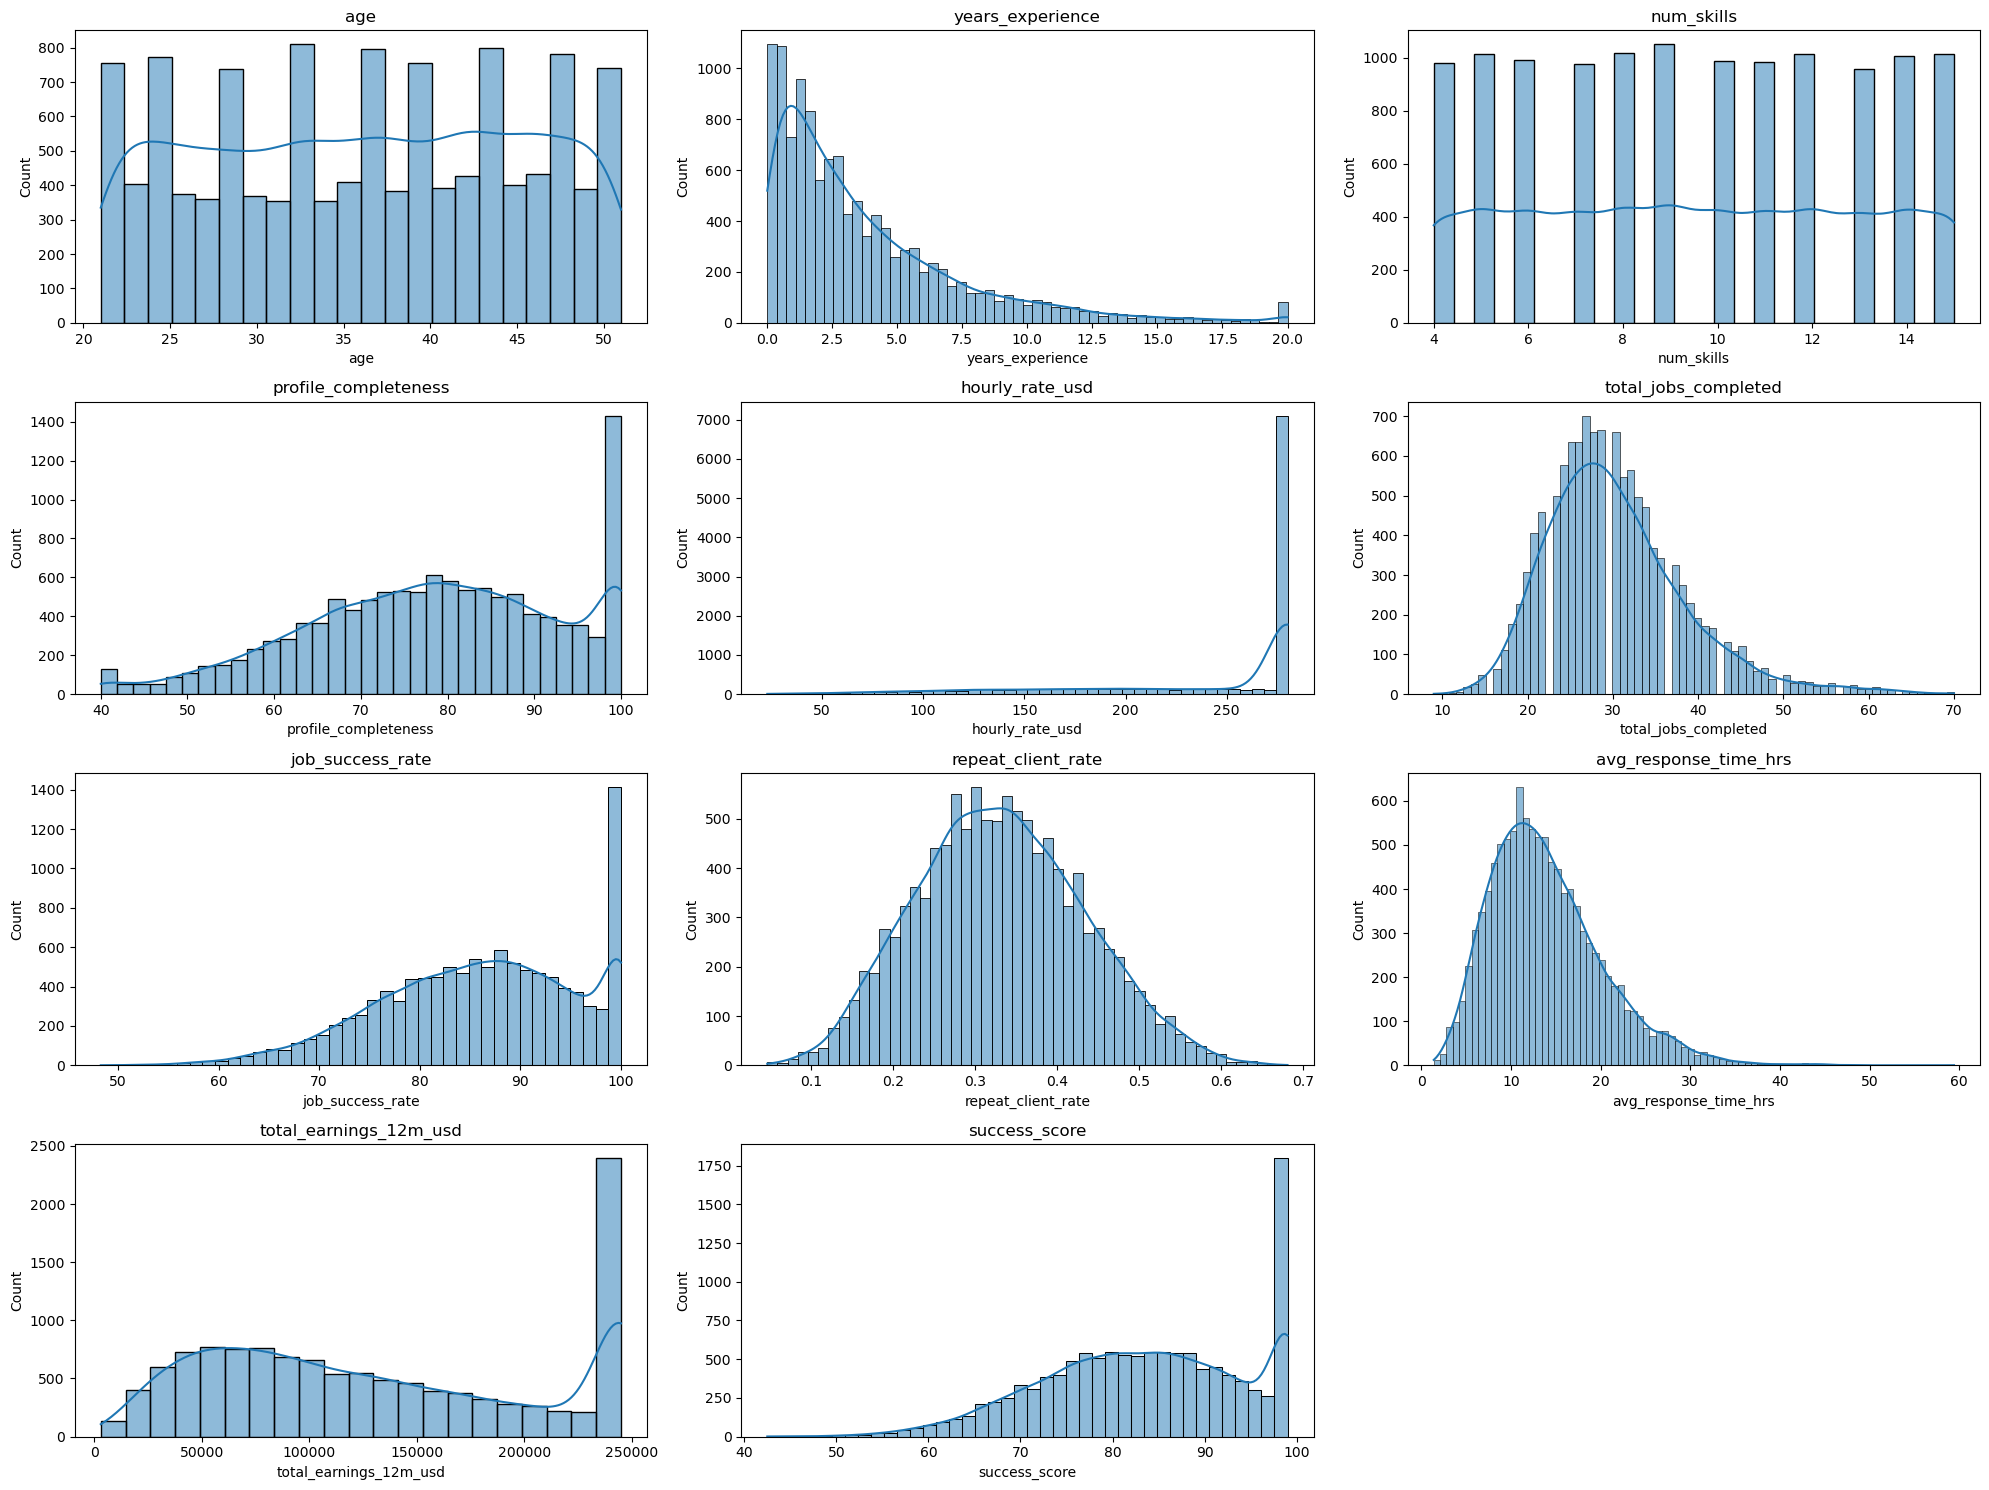

In [12]:
# visulization
plt.figure(figsize=(20,15))
for i, col in enumerate(num_cols, 1):
  plt.subplot(4,3,i)
  sns.histplot(df[col], kde=True)
  plt.title(col)

plt.tight_layout()
plt.savefig('numrical_distribution.png')

# 4. Categorical features

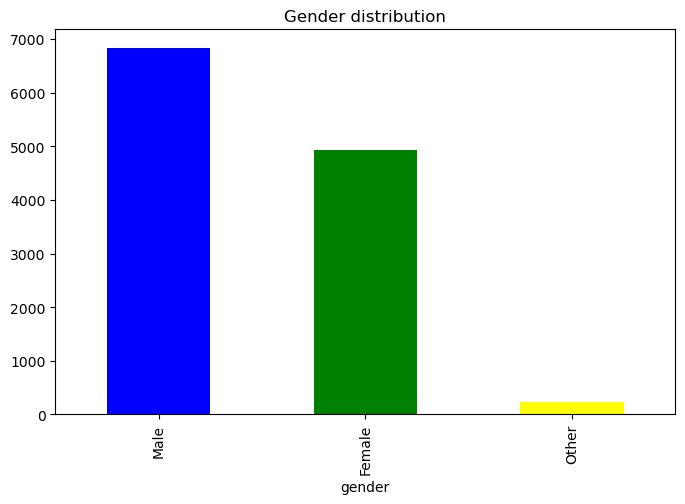

In [17]:
# gender distribution

plt.figure(figsize=(8,5))
df['gender'].value_counts().plot(kind='bar', color=['blue','green','yellow'])
plt.title('Gender distribution')
plt.savefig('figure/gender_distribution.png')

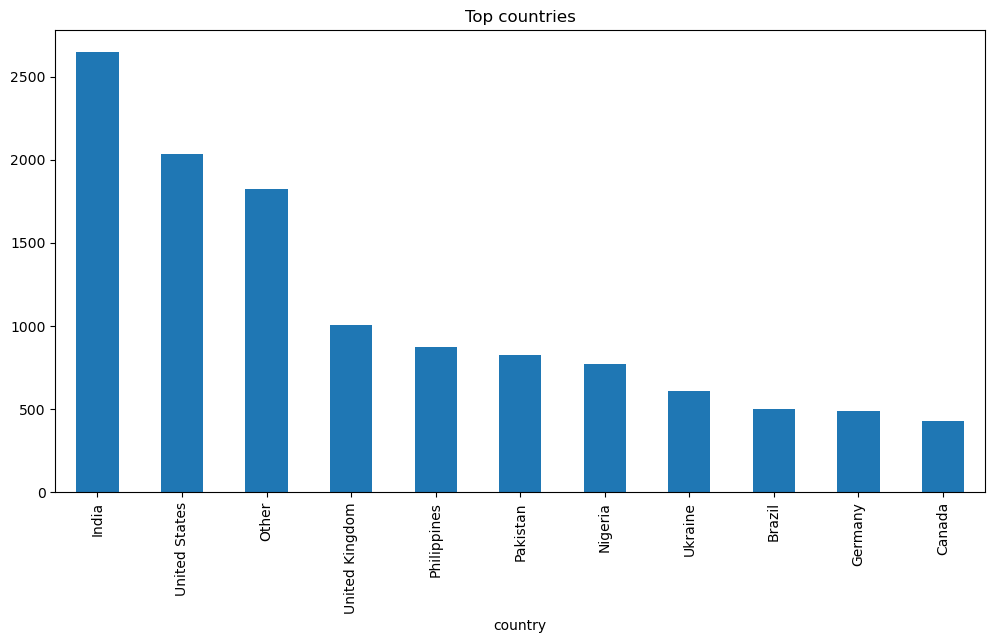

In [22]:
# Top countries
plt.figure(figsize=(12,6))
df['country'].value_counts().plot(kind='bar')
plt.title('Top countries')
plt.savefig('figure/top_countries.png')

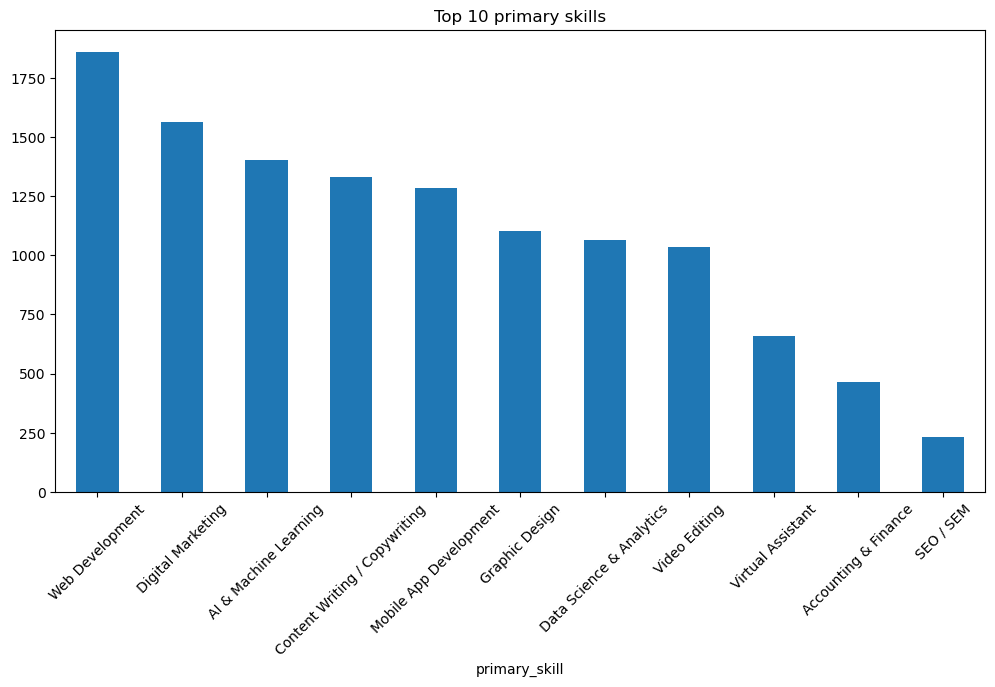

In [25]:
# top skills
plt.figure(figsize=(12,6))
df['primary_skill'].value_counts().plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Top 10 primary skills')
plt.savefig('figure/primary_skills.png')